In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


X_train, y_train, X_test, y_test = joblib.load("../data/processed_data.pkl")
feature_names = joblib.load("../data/feature_names.pkl")

print("Data loaded successfully")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Data loaded successfully
Train: (454902, 38), Test: (56962, 38)


In [2]:
models = {
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        colsample_bytree=0.6,
        gamma=1,
        min_child_weight=100,
        subsample=1.0,
        random_state=42,
        verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        colsample_bytree=0.6,
        min_child_samples=100,
        random_state=42,
        verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=4,
        learning_rate=0.1,
        random_state=42,
        verbose=0
    ),
}

# Stacked Ensemble: XGB + LGBM + CatBoost → Logistic Regression meta-learner
estimators = [
    ("xgb", models["XGBoost"]),
    ("lgbm", models["LightGBM"]),
    ("cat", models["CatBoost"]),
]
models["Stacked Ensemble"] = StackingClassifier(
    estimators=estimators,
    final_estimator=make_pipeline(StandardScaler(), LogisticRegression()),
    cv=3,
    n_jobs=-1
)

In [3]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    print(f"Training {name}...")
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)

    roc_auc  = metrics.roc_auc_score(y_te, y_prob)
    pr_auc   = metrics.average_precision_score(y_te, y_prob)
    f1       = metrics.f1_score(y_te, y_pred)
    precision = metrics.precision_score(y_te, y_pred)
    recall   = metrics.recall_score(y_te, y_pred)

    return {
        "Model": name,
        "ROC-AUC": round(roc_auc, 4),
        "PR-AUC": round(pr_auc, 4),
        "F1 Score": round(f1, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "_probs": y_prob,
    }

results = []
for name, model in models.items():
    result = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results.append(result)
    joblib.dump(model, f"../models/{name.replace(' ', '_').lower()}.pkl")
    print(f"  ✓ ROC-AUC: {result['ROC-AUC']}  PR-AUC: {result['PR-AUC']}\n")

Training XGBoost...
  ✓ ROC-AUC: 0.9773  PR-AUC: 0.8369

Training LightGBM...
  ✓ ROC-AUC: 0.9808  PR-AUC: 0.852

Training CatBoost...
  ✓ ROC-AUC: 0.9798  PR-AUC: 0.8143

Training Stacked Ensemble...
  ✓ ROC-AUC: 0.9797  PR-AUC: 0.8575



In [4]:
leaderboard = pd.DataFrame([{k: v for k, v in r.items() if k != "_probs"} for r in results])
leaderboard = leaderboard.sort_values("PR-AUC", ascending=False).reset_index(drop=True)
leaderboard.index += 1  # rank starts at 1
print("\n🏆 MODEL LEADERBOARD")
print(leaderboard.to_string())
leaderboard.to_csv("../models/leaderboard.csv", index=False)


🏆 MODEL LEADERBOARD
              Model  ROC-AUC  PR-AUC  F1 Score  Precision  Recall
1  Stacked Ensemble   0.9797  0.8575    0.7671     0.6942  0.8571
2          LightGBM   0.9808  0.8520    0.8038     0.7568  0.8571
3           XGBoost   0.9773  0.8369    0.7083     0.5986  0.8673
4          CatBoost   0.9798  0.8143    0.7456     0.6538  0.8673


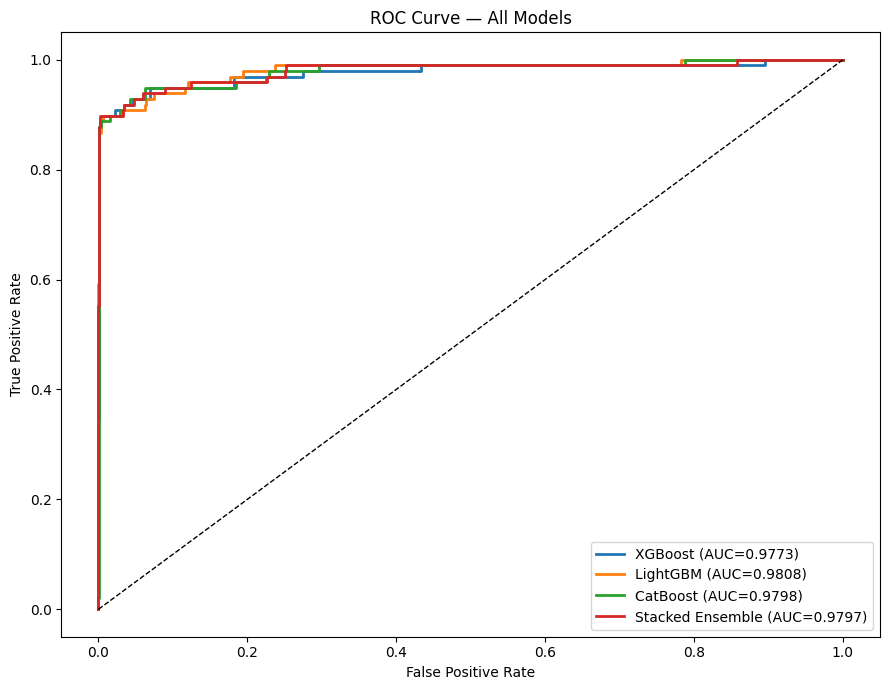

In [5]:
plt.figure(figsize=(9, 7))

for r in results:
    fp, tp, _ = metrics.roc_curve(y_test, r["_probs"])
    plt.plot(fp, tp, label=f"{r['Model']} (AUC={r['ROC-AUC']})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../models/roc_comparison.png", dpi=150)
plt.show()

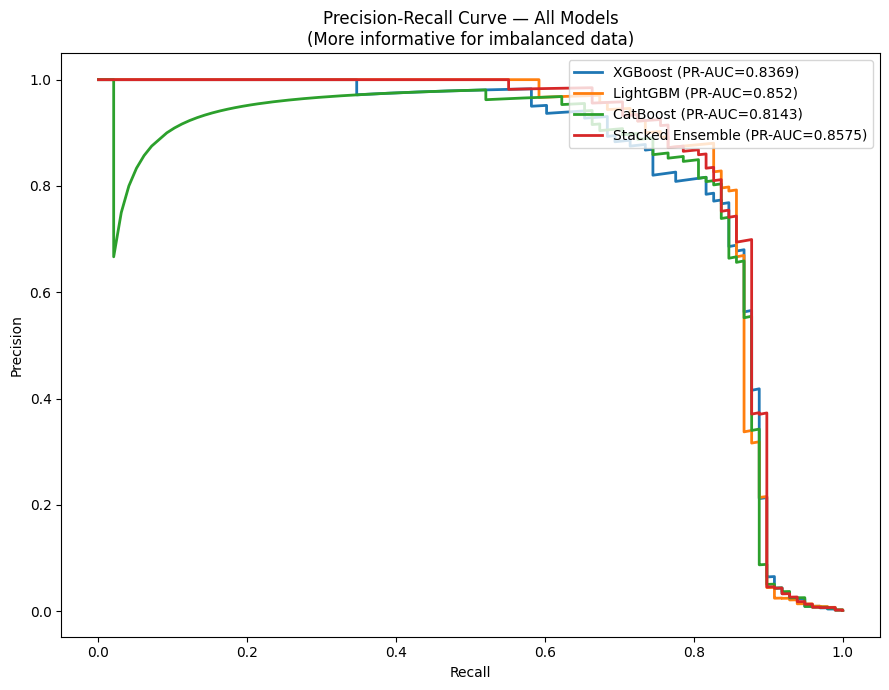

In [6]:
plt.figure(figsize=(9, 7))

for r in results:
    prec, rec, _ = metrics.precision_recall_curve(y_test, r["_probs"])
    plt.plot(rec, prec, label=f"{r['Model']} (PR-AUC={r['PR-AUC']})", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — All Models\n(More informative for imbalanced data)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../models/pr_comparison.png", dpi=150)
plt.show()

In [7]:
best_model_name = leaderboard.iloc[0]["Model"]
best_model = joblib.load(f"../models/{best_model_name.replace(' ', '_').lower()}.pkl")
joblib.dump(best_model, "../models/best_model.pkl")
print(f"Best model: {best_model_name}")

Best model: Stacked Ensemble
